# Results Analysis: Accuracy and Generalization of SAM with Adaptive Optimizers
In this notebook, we explore how Sharpness-Aware Minimization (SAM) interacts with the adaptive optimizer AdamW. Using CIFAR-10 and ResNet-18, we compare SGD, AdamW, and their SAM-based counterparts in terms of final accuracy and generalization gap across multiple random seeds.

In [3]:
import pandas as pd
from pathlib import Path

In [6]:
# Root results folder
root = Path("../results/30epoch")
summary_files = list(root.glob("**/summary.csv"))

print(f"Found {len(summary_files)} summary files")

Found 12 summary files


load and merge

In [7]:
dfs = []

for f in summary_files:
    df = pd.read_csv(f)
    dfs.append(df)

all_results = pd.concat(dfs, ignore_index=True)
all_results

,timestamp,run_name,dataset,model,optimizer,rho,adaptive,learning_rate,weight_decay,batch_size,epochs,seed,best_val_acc,best_val_epoch,train_acc_at_best,final_val_acc,final_train_acc,runtime_sec
0,20251213-135653,cifar10_resnet18_adamw_lr0.1_wd0.0005_bs512_seed0,cifar10,resnet18,adamw,0.05,False,0.1,0.0005,512,30,0,0.7773,28,0.76916,0.7759,0.77008,1931.300479
1,20251213-153519,cifar10_resnet18_adamw_lr0.1_wd0.0005_bs512_seed1,cifar10,resnet18,adamw,0.05,False,0.1,0.0005,512,30,1,0.7999,28,0.79152,0.7994,0.79150,1918.305143
2,20251213-160725,cifar10_resnet18_adamw_lr0.1_wd0.0005_bs512_seed2,cifar10,resnet18,adamw,0.05,False,0.1,0.0005,512,30,2,0.7420,29,0.72998,0.7420,0.72998,1890.715592
3,20251213-142914,cifar10_resnet18_sam_adamw_rho0.05_adaptive0_l...,cifar10,resnet18,sam_adamw,0.05,False,0.1,0.0005,512,30,0,0.7926,28,0.78228,0.7909,0.78490,3119.220911
4,20251213-041648,cifar10_resnet18_sam_adamw_rho0.05_adaptive0_l...,cifar10,resnet18,sam_adamw,0.05,False,0.1,0.0005,512,30,1,0.7241,29,0.70818,0.7241,0.70818,2965.721747
5,20251213-053657,cifar10_resnet18_sam_adamw_rho0.05_adaptive0_l...,cifar10,resnet18,sam_adamw,0.05,False,0.1,0.0005,512,30,2,0.7863,28,0.77808,0.7836,0.77732,2958.671264
6,20251212-223849,cifar10_resnet18_sam_sgd_rho0.05_adaptive0_lr0...,cifar10,resnet18,sam_sgd,0.05,False,0.1,0.0005,512,30,0,0.8437,29,0.84298,0.8437,0.84298,3042.133287
7,20251213-000213,cifar10_resnet18_sam_sgd_rho0.05_adaptive0_lr0...,cifar10,resnet18,sam_sgd,0.05,False,0.1,0.0005,512,30,0,0.8454,29,0.84164,0.8454,0.84164,3041.615607
8,20251213-012425,cifar10_resnet18_sam_sgd_rho0.05_adaptive0_lr0...,cifar10,resnet18,sam_sgd,0.05,False,0.1,0.0005,512,30,1,0.7556,28,0.74292,0.7551,0.74742,2983.952825
9,20251213-024542,cifar10_resnet18_sam_sgd_rho0.05_adaptive0_lr0...,cifar10,resnet18,sam_sgd,0.05,False,0.1,0.0005,512,30,2,0.8153,29,0.80714,0.8153,0.80714,3008.931424


In [10]:
df = all_results[
    (all_results["dataset"] == "cifar10") &
    (all_results["model"] == "resnet18") &
    (all_results["epochs"] == 30)
]

## 4. 1. Accuracy Score Analysis

In [18]:
summary_4_1 = (
    df
    .groupby("optimizer")
    .agg(
        test_acc_mean=("best_val_acc", "mean"),
        test_acc_std=("best_val_acc", "std"),
    )
    .reset_index()
)

# convert to percentage
summary_4_1["test_acc_mean"] *= 100
summary_4_1["test_acc_std"] *= 100

summary_4_1

,optimizer,test_acc_mean,test_acc_std
0,adamw,77.306667,2.918122
1,sam_adamw,76.766667,3.786111
2,sam_sgd,81.500000,4.193765
3,sgd,87.747500,0.510906


## 4. 2. Convergency Analysis

In [20]:
def load_epoch_data(root, optimizer_name):
    records = []

    for seed in [0, 1, 2]:
        path = root / f"cifar10_{optimizer_name}_seed{seed}" / "epochs"
        csv_file = list(path.glob("*.csv"))[0]

        df = pd.read_csv(csv_file)
        df["seed"] = seed
        records.append(df)

    return pd.concat(records, ignore_index=True)

def load_and_aggregate(optimizer_name):
    dfs = []
    for seed in [0, 1, 2]:
        path = root / f"cifar10_{optimizer_name}_seed{seed}" / "epochs"
        csv_file = list(path.glob("*.csv"))[0]

        df = pd.read_csv(csv_file)
        df["seed"] = seed
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    agg = (
        df_all
        .groupby("epoch")
        .agg(
            val_acc_mean=("val_acc", "mean"),
            val_acc_std=("val_acc", "std")
        )
        .reset_index()
    )
    return agg


SAM (SGD) and SGD

In [24]:
NAVY = "#1f3a5f"
ORANGE = "#f28e2b"

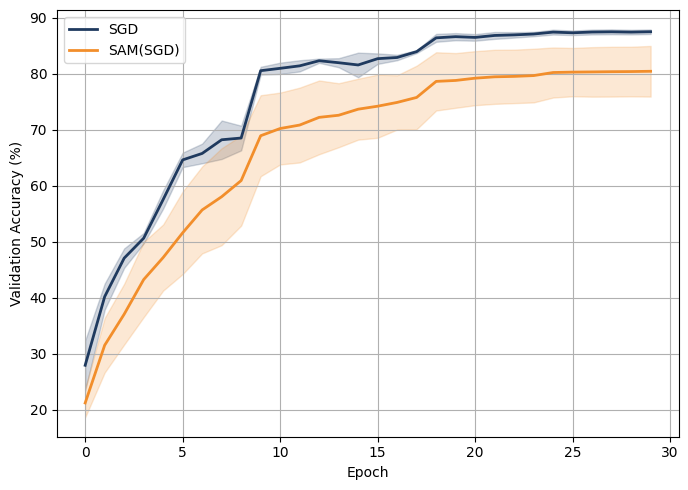

In [25]:
import matplotlib.pyplot as plt

sgd = load_and_aggregate("sgd")
sam_sgd = load_and_aggregate("sam_sgd")

plt.figure(figsize=(7, 5))

# SGD
plt.plot(
    sgd["epoch"],
    sgd["val_acc_mean"] * 100,
    label="SGD",
    color=NAVY,
    linewidth=2
)
plt.fill_between(
    sgd["epoch"],
    (sgd["val_acc_mean"] - sgd["val_acc_std"]) * 100,
    (sgd["val_acc_mean"] + sgd["val_acc_std"]) * 100,
    color=NAVY,
    alpha=0.2
)

# SAM(SGD)
plt.plot(
    sam_sgd["epoch"],
    sam_sgd["val_acc_mean"] * 100,
    label="SAM(SGD)",
    color=ORANGE,
    linewidth=2
)
plt.fill_between(
    sam_sgd["epoch"],
    (sam_sgd["val_acc_mean"] - sam_sgd["val_acc_std"]) * 100,
    (sam_sgd["val_acc_mean"] + sam_sgd["val_acc_std"]) * 100,
    color=ORANGE,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
plt.savefig(
    "fig_sgd_vs_sam_sgd.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

SAM (ADAMW) and ADAMW

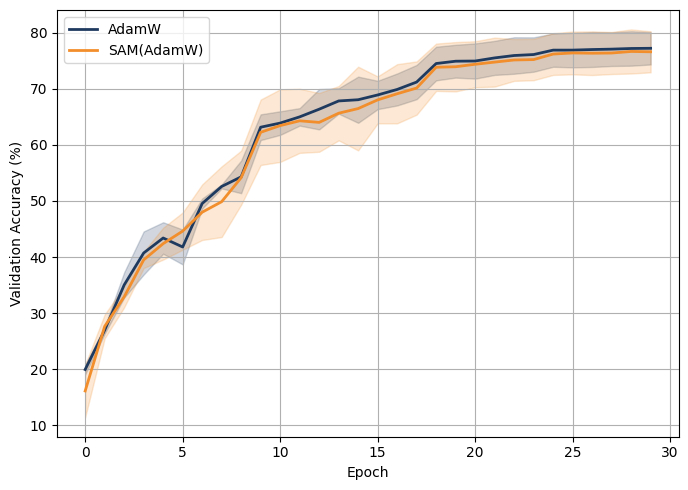

In [26]:
adamw = load_and_aggregate("adamw")
sam_adamw = load_and_aggregate("sam_adamw")

plt.figure(figsize=(7, 5))

# AdamW
plt.plot(
    adamw["epoch"],
    adamw["val_acc_mean"] * 100,
    label="AdamW",
    color=NAVY,
    linewidth=2
)
plt.fill_between(
    adamw["epoch"],
    (adamw["val_acc_mean"] - adamw["val_acc_std"]) * 100,
    (adamw["val_acc_mean"] + adamw["val_acc_std"]) * 100,
    color=NAVY,
    alpha=0.2
)

# SAM(AdamW)
plt.plot(
    sam_adamw["epoch"],
    sam_adamw["val_acc_mean"] * 100,
    label="SAM(AdamW)",
    color=ORANGE,
    linewidth=2
)
plt.fill_between(
    sam_adamw["epoch"],
    (sam_adamw["val_acc_mean"] - sam_adamw["val_acc_std"]) * 100,
    (sam_adamw["val_acc_mean"] + sam_adamw["val_acc_std"]) * 100,
    color=ORANGE,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
plt.savefig(
    "fig_adamw_vs_sam_adamw.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()